<div style="float: right; font-size: 15pt;"><a href="https://people.epfl.ch/paolo.prandoni">Paolo Prandoni</a>, <a href="https://www.epfl.ch/">EPFL</a></div>
<div style="clear: both;"></div>

<h1 style="font-size: 30pt; color: #B51F1F;">From natural numbers all the way to Euler's formula,<br>without calculus</h1>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9,2.5)

# Credits

<img src="img/feynman.png" style="float: right; width: 400px; margin: -40px 10px;"/>

Freely adapted from Richard Feynman's lecture _"Algebra"_, given at Caltech in January 1962. 

Full text (and audio) of the original lecture available at [https://www.feynmanlectures.caltech.edu/I_22.html](https://www.feynmanlectures.caltech.edu/I_22.html).

<br><br><br><br><br><br><br><br>

# Introduction

Euler's formula, one of the most fascinating and astonishing expressions in mathematics, establishes a profound and unexpected link between trigonometric functions, complex exponentiation, the imaginary unit ($j$) and the natural base for logarithms ($e$): 

$$
 e^{jx} = \cos x + j \sin x
$$

On top of its deep mathematical significance, the formula is also a surprisignly useful practical tool that is used ubiquitously in physics and engineering; for example, using Euler's formula, trigonometric identities become simple algebraic identities that no longer require memorization:
$$
    \sin a \, \sin b = \left(\frac{e^{ja} - e^{-ja}}{2j}\right) \left(\frac{e^{jb} - e^{-jb}}{2j}\right) = -\frac{e^{j(a+b)} - e^{j(a-b)}}{4} - \frac{e^{-j(a-b)} + e^{-j(a+b)}}{4} = \frac{1}{2}\cos(a-b) - \frac{1}{2}\cos(a+b);
$$
similarly, the use of complex exponentials greatly simplifies the expression for the Fourier transform, with no need to separate even and odd basis functions anymore:
$$
    \hat{y}(f) = \int_{-\infty}^{\infty} y(t)\,e^{-j2\pi ft}\, dt
$$

Because of its widespread use in mathematical derivations, the reasons "why" Euler's formula "works" are often forgotten, unclear, or remembered in excessively technical form; if asked, an engineering student will probably say something about separating the even- and odd-indexed terms in the series for the exponential function, and recognizing them as the Taylor expansions of the cosine and sine functions:
$$
e^{jx} = \sum\limits_{k=0}^{\infty}\frac{(jx)^k}{k!} = 1+jx-\frac{x^2}{2!}-j\frac{x^3}{3!}+\frac{x^4}{4!}+\dots;
$$
but this "mechanical" proof, which merely invokes other advanced results from calculus, obviously misses the point entirely and provides no intuitive justification as to why the formula should make sense. 

<br><br>

In a famous 1962 Caltech lecture called "Algebra", the Nobel laureate theoretical physicist [Richard Feynman](https://en.wikipedia.org/wiki/Richard_Feynman) provided the audience with a masterful intuitive derivation of Euler's formula, which he calls "the jewel of mathematics". Feynman starts from the simplest and most immediate mathematical concept, the natural numbers, and arrives at the final destination using nothing more than elementary arithmetic, that is, sums, products, and divisions that can be computed with pen and paper (and some patience). The journey beautifully illustrate the process that led to the power of modern mathematics: on one hand, the emergence of increasingly sophisticated questions about the world required the "invention" of increasingly more sophisticated number systems; on the other hand, new numbers and new operations had to be "backwards compatible" (to use a modern term) with the properties of their predecessors. Step by step, Feynman takes us through the birth of negative numbers, fractions, irrational numbers and, finally, complex numbers; and, once there, with a final sleigh of hand that is as brilliant as it is obvious in hindsight, he shows us the emergence of Euler's formula from simple numerical calculations. 

The following slides are but a terse summary of the lecture, with a few minor changes here and there to better leverage the general knowledge of today's students (for instance, their familiarity with binary numbers); of course, the original source is a marvelous show onto itself, and can perhaps be appreciated even better after going through the following succint synopsis.

# Notation and conventions

 * we start from natural numbers: $\mathbb{N} = \{0, 1, 2, 3, \ldots\}$, and then move on to
     * integers $\mathbb{Z} = \{0, \pm 1, \pm 2, \pm  3, \ldots\}$
     * rationals: $\mathbb{Q} = \{A/B, A\in\mathbb{Z}, B\in\mathbb{N}^+\}$
     * reals: $\mathbb{R}$, and complex: $\mathbb{C}$
 * integers will be indicated by uppercase letters, all other numbers with lowercase
 * all numerical algorithms use only additions and multiplications

# Intuitive elementary operations on the naturals

## Addition
 * with its obvious properties:
   * $A + B = B+ A$ (commutativity)
   * $A + (B + C) = (A + B) + C$ (distributivity)
   * $A + 0 = A$ (identity)

## Multiplication
 * repeated addition is multiplication: $\underbrace{A + A + \ldots + A}_{B \text{ times}} = AB$
 * multiplication is _defined_ to have certain properties, and to play well with addition:
   * $AB = BA$  (commutativity)
   * $A\,(BC) = (AB)\,C$ (distributivity)
   * $A\,(B + C) = AB + AC$ (distributivity wrt addition)
   * $A \cdot 1 = A$ (identity)

<br>
     
 * we can start to "prove" additional properties such as  $A \cdot 0 = 0$:
   1. from the additive identity $B + 0 = B$ we can say $A\,(B+0) = AB$ 
   1. from the multiplicative distributivity we have $A\,(B+0) = AB + A \cdot 0$
   1. but so $AB = AB + A \cdot 0$ and therefore $A \cdot 0 = 0$

## Exponentiation

 * repeated multiplication is integer exponentiation: $\underbrace{A \cdot A \cdot \ldots \cdot A}_{B \text{ times}} = A^B$
 * with obvious properties derived from multiplication
   * $(AB)^C = A^CB^C$
   * $A^B\,A^C = A^{(B+C)}$
   * $(A^B)^C = A^{(BC)}$
   * $A^1 = A$
     
<br>  

 * let's show that $A^0 = 1$
   1. from the additive identity $B + 0 = B$ we can say $A^{(B+0)} = A^B$ 
   1. we know $A^B\,A^C = A^{(B+C)}$ so $A^{(B+0)} = A^B\,A^0$ 
   1. therfore $A^B = A^B A^0$ and so $A^0 = 1$

# Positional notation (part 1)

For now we haven't talked about how to _write_ numbers. Of course we're familiar with the decimal notation but the general principle is the following:

 * choose a base (or _radix_) $R$ and a set of symbols $\mathcal{R}$ to represent the first $R$ integers
 * count from zero up to $R-1$, then from $(R)+0$ to $(R) + (R-1)$, then from $(2B) + 0$ to $(2R) + (R-1)$ etc etc 
 * the notation $[A_3 A_2 A_1 A_0]$ with $A_k\in \mathcal{R}$ represents the number $A = A_2\, R^2 +  A_1\,R^1 + A_0\,R^0$

| notation | base | digits | example |
|---:|:---:|:---|---:|
| decimal | 10 | 0, 1, 2, 3, 4, 5, 6, 7, 8, 9 | 1935 |
| binary  |  2 | 0, 1  | 0111 1000 1111  | 
| octal   |  8 | 0, 1, 2, 3, 4, 5, 6, 7 | 3617 |
| hexadecimal  | 16  | 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, A, B, C, D, E, F | 78F  | 

Changing the base for integers requires only elementary operations:

In [11]:
def change_base_int(A: int, R: int) -> str:
    digits = [0]
    # simply increment integer in base R until we reach X
    for n in range(A):
        carry = 1
        for m in range(len(digits)):
            digits[m] += carry
            if digits[m] == R:
                digits[m] = 0
            else:
                carry = 0
                break
        if carry == 1:
            digits.append(1)
    return ''.join(chr(d+48+(7 if d > 9 else 0)) for d in digits[::-1])    

In [12]:
change_base_int(255, 16)

'FF'

In [13]:
change_base_int(32767, 2)

'111111111111111'

# Things become more interesting with inverse operations

Integer addition and multiplication are fine but of course we start to ask obvious questions:

## first inverse operation: subtraction

 * if I have 3 apples and you give me two more, easy: $3 + 5 = 8$
 * if I have 8 apples and I eat three, equally easy: $8 - 3 = 5$
 * subtraction is defined as the inverse of addition: $A = B + C \Rightarrow C = A - B$
 * but what if $B > A$?

## second inverse operation: division

 * if i have 3 friends and each brings me four apples, easy: $3\cdot 4 = 12$
 * if i have 12 apples and I split them among my 3 friend, easy: $12 / 3 = 4$
 * division is defined as the inverse of multiplication: $A = BC \Rightarrow B = A/C$
 * but what if $A < C$? What if $C=0$?

## inverse operations

summary of inverse operations: if you start with $A, B \in \mathbb{N}$ and compute $C$, then you can always go back:

 * $A + B = C \quad\rightarrow\quad A = C - B, \quad B=C-A$
 * $AB = C \quad\rightarrow\quad A = C/B, \quad B = C/A$
 * $A^B = C \quad\rightarrow\quad A = \sqrt[B]C, \quad B = \log_A C$

Of course, the moment you pick $C$ arbitrarily, these inverse operations will not have a solution in $\mathbb{N}$ anymore.

# First extension of the set of numbers, from $\mathbb{N}$ to $\mathbb{Z}$ 

 * to make subtraction work in all cases we "invent" negative numbers
 * **key point**: we had lots of properties for addition and multiplication! Do they still work with negative numbers?
 * it turns out that they do, **if** we set the correct _sign rules_ for multiplication:

|   | (+) | (-) |
|---|---|---|
| **(+)** | + | - |
| **(-)** | - | + |

# Second extension, from $\mathbb{Z}$ to $\mathbb{Q}$ 

 * to make division work in (almost) all cases, we "invent" rational numbers
 * all the nice properties of addition and multiplication still work, but only if we add an **extra rule:** _division by zero is not allowed!_

## Negative exponents
 * if we allow negative numbers, we need to **define the meaning** of $A^{-B}$ 
 * assuming the rules hold, $A^{-B} = (A^{-1})^B$ so we only need to define the meaning of $A^{-1}$
 * $A^{-1}\,A^1 = A^{(1-1)} = A^0 = 1$; since we can now use division, $A^{-1} = 1 / A$

# Positional notation (part 2)

Now that we have fractional numbers, we can extend the positional notation to represent elements in $\mathbb{Q}$

 * a rational $q = C/D$ can always be reduced to $q = \pm(A + a)$ with $A \in \mathbb{N}$ and $0 \le a < 1$ 
 * in base $R$, the notation $[A_3 A_2 A_1 A_0.A_{-1} A_{-2} A_{-3}]$ represents the number  $A = A_2\, R^2 + A_1\,R + A_0 + A_{-1}\,R^{-1} + A_{-2}\,R^{-2} + A_{-3}\,R^{-3}$

| notation | base |  | |
|---:|:---:|:---:|:---|
| decimal | 10 | $0.5$ | $0.3$ |
| binary  |  2 | $0.1$  | $0.01 \overline{0011}$ | 
| octal   |  8 | $0.4$ | $0.2 \overline{3146}$ |
| hexadecimal | 8 | $0.8$   |$0.4 \overline{C}$ | 

Changing the base for rationals also requires only elementary operations:

In [22]:
def change_base_frac(a: float, R: int, places=32) -> str:
    A = ('-' if a < 0 else '') + change_base_int(int(np.abs(a)), R)
    a = a - int(np.abs(a))
    digits, last = np.zeros(places).astype(int), 0
    for n in range(places):
        a *= R
        digits[n] = int(a)
        a -= digits[n]
        if digits[n] != 0:
            last = n
    return A + '.' + ''.join(chr(d+48+(7 if d > 9 else 0)) for d in digits[:last+1])    

In [23]:
change_base_frac(0.6875, 2)

'0.1011'

# Third extension of the set of numbers, from $\mathbb{Q}$ to $\mathbb{R}$ 

 * Now that we have rationals, what is the meaning of $A^{(1/B)}$ ?
 * once again, we can invoke the exponentiation properties and say  $(A^{(1/B)})^B = A^1 = A$
 * let's define the inverse of exponentiation, aka the **root**: if $C^B = A$ then $C = \sqrt[B]{A}$
 * therefore $A^{(1/B)} = \sqrt[B]{A}$

Of course, in $\mathbb{Q}$, roots are well defined only in special cases, such as $\sqrt{4}, \, \sqrt[3]{27/8}, \, \sqrt[4]{1/625}, \ldots$ so we need to "expand" the rationals to the reals

## Irrationality of $\sqrt{2}$

This bothered the ancient Greeks a lot and explains why $\mathbb{Q}$ is not enough:

 * assume $A, B \in \mathbb{N}$ are coprime (no common factors) and $(A/B)^2 = 2$; then
   * $A^2 = 2B^2$ so $A^2$ is even
   * if $A^2$ is even then $A$ must be even, so $A = 2C$ for some integer $C$
   * $B^2 = A^2/2 = (2C)^2/2 = 2C^2$ so $B^2$ is also even; which means $B$ is even, contradicting the coprimality hypothesis for $A$ and $B$

# What about actual numerical methods?

We have defined increasingly complex number systems and operations but we only know very simple numerical algorithms (the ones you learn in elementary school): addition/subtraction and multiplication/division.

But what if you want to compute something like $17^{3.673}$ or $\log_{7} 12.5$? Where do we start? Can we do it by hand?

Interestingly, we can get away with just one extra algorithm, the one to compute square roots

## Computing square roots

Luckily, it's easy to compute square roots using only multiplications and divisions
 * easiest method is the "Babylonian algorithm" (1st century AD)
 * basically, it's Newton-Rhapson's zero-finding algorithm applied to the function $f(x) = a - x^2$
 * convergence is very fast
 * it can be computed by hand

In [27]:
def sqroot(x, iterations=10):
    s = x / 2
    for n in range(iterations):
        s = (s + x / s) / 2
    return s

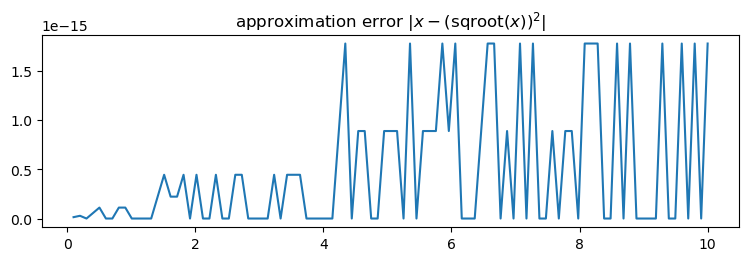

In [28]:
x = np.linspace(0, 10, 100)[1:]
plt.plot(x, np.abs(x -  sqroot(x) ** 2));
plt.title('approximation error $|x - (\\text{sqroot}(x))^2|$'); 

## Computing fractional powers 

With square roots we can now compute complicated powers:

 * for any $s \in \mathbb{R}^+$, we can write $s = X + x$ with $X\in\mathbb{N}$ and $0 \le x < 1$
 * $a^s = a^X\,a^x$, and the first we know how to compute

 * express $x$ in binary notation:
   $$
        x = \sum_{k=1}^{\infty} X_{-k}2^{-k} = X_{-1}{2}^{-1} + X_{-2}2^{-2} + X_{-3}2^{-^3} + X_{-4}2^{-4} + \ldots \qquad X_{-k} \in \{0, 1\}
   $$
 * we can then compute $a^x$ from the "power-of-two" roots of $a$
   $$
        a^x = a^{\sum_{k=1}^{\infty} X_{-k}\,2^{-k}} = \prod_{k | X_{-k} = 1} \sqrt[2^k]{a}
   $$

### example: compute $10^{0.6875}$
 * $[0.6875]_{10} = [0.1011]_{2}$
 * $10^{0.6875} = 10^{\frac{1}{2} + \frac{1}{8} + \frac{1}{16}} = \sqrt[2]{10} \cdot \sqrt[8]{10} \cdot \sqrt[16]{10} = \sqrt{10} \cdot \sqrt{\sqrt{\sqrt{10}}} \cdot \sqrt{\sqrt{\sqrt{\sqrt{10}}}}$
 * $10^{0.6875} \approx 4.8697$ 

In [31]:
def power(a, x):
    assert 0 < x < 1, f'exponent must be in (0, 1)'
    b = 1
    for bit in change_base_frac(x, 2, 32)[2:]:
        a = sqroot(a)
        if bit == '1':
            b *= a
    return b

In [32]:
power(10, 0.6875)

4.869675251658631

## Computing logarithms

Similarly, we can compute logarithms using iterated square roots (and that's how the logarithm tables were originally computed by hand)

 * we want to compute $x = \log_a b$ for $1 < b < a$ <br>
   (if $a^ N < b < a^{N+1}$, set $b' = b/a^N$; then $1 < b' < a$ and $\log_a b = N\log_a b'$)<br><br>
 * we know $0 < x < 1$ and $b = a^x = \prod_{k} \sqrt[2^k]{a}$, where the product contains the factors associated to the "ones" in the binary representation of $x$
 * to find $x$ in binary form, we can iteratively divide $b$ by $\sqrt[2^k]{a}$ and set $X_{-k} = 1$ when the divisor fits
 * in the end, $\log_a b = \sum_k X_{-k}2^{-k}$

### example: compute $\log_{10} 2$
 * $2 < \sqrt{10}$ so $X_{-1} = 0$
 * $2 \ge \sqrt[4]{10}$ so $X_{-2} = 1$; $2 / \sqrt[4]{10} = 1.12468$
 * $1.12468 < \sqrt[8]{10}$ so $X_{-3} = 0$
 * $1.12468 \ge \sqrt[16]{10}$ so $X_{-4} = 0$
 * $1.12468 < \sqrt[32]{10}$ so $X_{-5} = 1$; ...
 * $\log_{10} 2 \approx [0.01001]_{2} = 0.28125$

In [35]:
def logarithm(b, a=10, N=32):
    assert 1 < b < a, f'argument must be in (1, {a})'
    x, d = 0, 1.0
    for n in range (N):
        d /= 2
        a = sqroot(a)
        if b > a:
            b /= a
            x += d
    return x

In [36]:
logarithm(2, 10)

0.3010299955494702

In [37]:
logarithm(3, 9)

0.49999999976716936

## Repeated square roots

The two previous numerical recipes required the computation of recursive square roots. Let's see what happens when we do that

 * let's compute $\sqrt{a},\, {\sqrt{\sqrt{a}}},\, \sqrt{\sqrt{\sqrt{a}}},\, \sqrt{\sqrt{\sqrt{\sqrt{a}}}}, $ etc.
 * start with $a[0] = a$ and at each step $a[n] = \sqrt{a[n-1]}$ using the Babylonian algorithm
 * we're computing the function $f(x) = a^{x}$ over the sequence $x[n] = 2^{-n}$

<br>

 * when doing this by hand, people noticed that for $x$ very small, $a^x \approx 1 + c_a x$
 * let's verify this numerically:
   * when $n$ is large, $a[n] = a^{1/2^n} \approx 1 + c_a 2^{-n}$
   * $c_a \approx (a[n-1] - a[n])/2^{-n} $

In [39]:
def root_of_root(a, N=30, M=20):
    x, r, c = np.zeros(M), np.zeros(M), np.zeros(M)
    for n in range(1, N):
        b = sqroot(a)
        if n >= N - M:
            i = n - N + M
            x[i] = 1 / (2 ** n)
            r[i] = b
            c[i] = (a - b) / x[i]
        a = b
    return x, r, c

[2.31036514 2.30647172 2.30452756 2.30355611 2.30307055 2.30282781
 2.30270645 2.30264577 2.30261543 2.30260026 2.30259268 2.30258888
 2.30258699 2.30258604 2.30258556 2.30258533 2.30258521 2.30258512
 2.30258512 2.30258512]


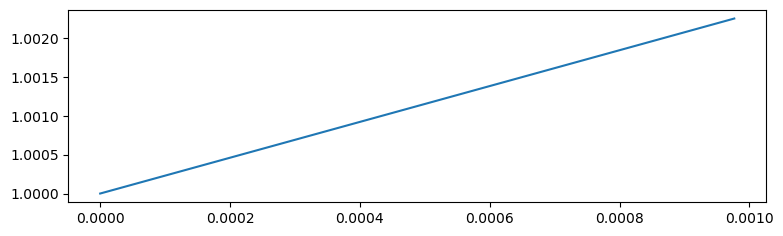

In [40]:
x, r, c = root_of_root(10)
plt.plot(x, r)
print(c)

[1.10038176 1.09949665 1.09905438 1.09883331 1.09872279 1.09866754
 1.09863991 1.0986261  1.09861919 1.09861574 1.09861402 1.09861315
 1.09861272 1.0986125  1.0986124  1.09861234 1.09861231 1.09861231
 1.09861231 1.09861231]


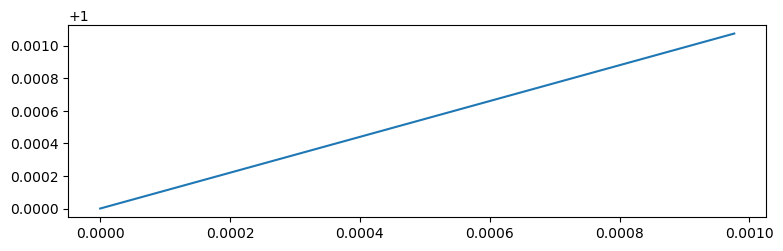

In [41]:
x, r, c = root_of_root(3)
plt.plot(x, r)
print(c)

## Euler's constant

If we look at the numerical value of $c_a$ as a function of $a$, there seems to exist a value $2 < \bar{a} < 3$ for which $c_\bar{a} = 1$ so that the small-exponent approximation is simple $\bar{a}^x \approx 1 + x$.

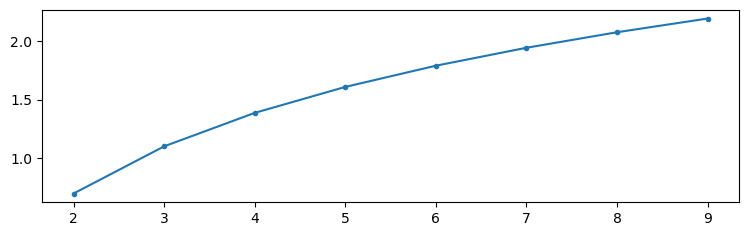

In [43]:
bases = np.arange(2, 10)
plt.plot(bases, [ root_of_root(a)[2][-1] for a in bases ], '.-');

Let's call this value $e$ instead of $\bar{a}$; ee can find the numerical value of $e$ as precisely as we want using binary search over the interval $[2, 3]$:

In [45]:
def find_e(iterations=20):
    i = np.array([2.0, 3.0])
    for n in range(iterations):
        m = np.mean(i)
        me = root_of_root(m)[2][-1]
        if me > 1:
            i[1] = m
        else:
            i[0] = m
    return m

In [46]:
find_e()

2.7182817459106445

We have found Euler's constant:

 * the repeated square roots of $e$ are simpler to compute a lot of decimals because the small-exponent approximation is easier
 * $e$ is called the natural base for exponentiation (and logarithm)

<br>
to compute everything in base $e$:

 * $a^x = e^{\ln a^x} = e^{x\ln a}$; we can see now that $c_a = \ln a$
 * if $a^x = b$ then $x = \log_a b$; but also: $\ln a^x = \ln b$ so $x = (\ln x)/(\ln a)$

# Final extension of the set of numbers, from $\mathbb{R}$ to $\mathbb{C}$ 

the final push:even using reals, we still can't solve problems such as $x^2 = -1$


 * for this we "invent" imaginary numbers: $z = a + jb$ with $j^2 = -1$
 * amazingly, addition and multiplication still work according to the rules!
 * and then the ultimate miracle: this is the last "expansion" we need in order to solve ALL algebraic problems!

Here is a simple implementation of complex multiplication:

In [49]:
def cmul(a: tuple, b: tuple) -> tuple:
    assert len(a) == len(b) == 2, 'operands shouldbe (real, imag) tuples'
    return (a[0] * b[0] - a[1] * b[1], a[0] * b[1] + a[1] * b[0])

In [50]:
# (1 + j)(1 -j) = 2
cmul((1, 1), (1, -1))

(2, 0)

Note how integer exponentiation of the imaginary unit resut in periodic sign alternations: $j^n = 1, j, -1, -j, 1, j, -1, -j, \ldots$

In [52]:
z = (0, 1)
for n in range(10):
    print(z, end=', ')
    z = cmul((0, 1), z)

(0, 1), (-1, 0), (0, -1), (1, 0), (0, 1), (-1, 0), (0, -1), (1, 0), (0, 1), (-1, 0), 

This is a crucial observation to understand the deep meaning of Euler's formula.

# Complex exponentiation

OK, now that we have imaginary numbers, we need to define the meaning of $a^z$ when $z$ is complex

 * let's assume that the standard exponentiation rules still work
 * if $z = y + jx$, $a^z = a^y\,a^{jx}$; the first term we know, so we focus on $a^{jx}$
   * since $a^{jx} = e^{jc_a x}$, we will study $e^{jx}$
   * again, we just need to consider $0 < x \le 1$, the rest follows

 * here's the trick: let's assume that the small-exponent approximation holds for imaginary numbers as well:
   $$
       e^{jx} \approx 1 + jx \quad \text{for $x$ small}
   $$

## computing complex exponentiation numerically

using the small-exponent approximation, let's compute $(e^{jx})^n = e^{jnx}$ for $x$ small:
 * $p[0] = 1 + j/1000 \approx e^{j/1000} $
 * $p[n+1] =  p[n](1 + j/1000) \approx e^{jn/1000}$
 * compute each step using the complex multiplication algorithm shown before

In [56]:
a = p = (1, 0.001)
N = 10000
real, imag = np.zeros(N), np.zeros(N)
for n in range(N):
    real[n], imag[n] = p
    p = cmul(p, a)

And now let's plot the real and imaginary parts over a large range for $n$:

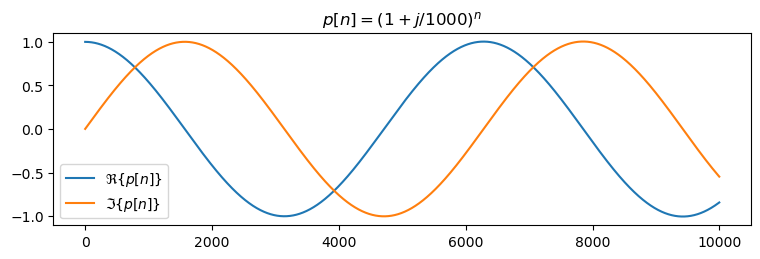

In [58]:
plt.plot(real, label='$\Re\{p[n]\}$');
plt.plot(imag, label='$\Im\{p[n]\}$');
plt.legend();
plt.title('$p[n] = (1 + j/1000)^n$');

when is $\Im\{e^{ja}) = 0$?

In [60]:
for n in range(len(imag) - 1):
    if imag[n] * imag[n+1] <= 0:
        print(f'Im{{p[n]}} = 0 for n/1000 = {n/1000}')
        print(f'Re{{p[{n}]}} = {real[n]}')
        break

Im{p[n]} = 0 for n/1000 = 3.14
Re{p[3140]} = -1.0015715565772998


and so, starting from first principles, we just found in a purely numerical way that:
 * $e^{jx} = \cos x + j \sin x$
 * $e^{j\pi} + 1 = 0$